<a href="https://colab.research.google.com/github/rickiepark/deep-learning-with-python-3rd/blob/main/chapter10_interpreting-what-convnets-learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이 노트북은 <[케라스 창시자에게 배우는 딥러닝 (개정 3판)](https://tensorflow.blog/kerasdl3/)>(길벗, 2026)의 예제 코드를 담고 있습니다.

In [1]:
!pip install keras keras-hub --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"이 셀은 {required} 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "
            f"\"{required}\"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요."
        )

In [4]:
import keras, keras_hub

print(keras.__version__)
print(keras_hub.__version__)

3.15.1
0.31.0


## 컨브넷이 학습한 것 해석하기

### 중간 활성화 시각화하기

In [5]:
# 코랩의 경우 아래 명령을 통해 깃허브에서 체크포인트를 다운로드합니다.
!wget https://github.com/rickiepark/deep-learning-with-python-3rd/raw/refs/heads/main/convnet_from_scratch_with_augmentation.keras

--2026-08-14 12:35:26--  https://github.com/rickiepark/deep-learning-with-python-3rd/raw/refs/heads/main/convnet_from_scratch_with_augmentation.keras
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/deep-learning-with-python-3rd/refs/heads/main/convnet_from_scratch_with_augmentation.keras [following]
--2026-08-14 12:35:26--  https://raw.githubusercontent.com/rickiepark/deep-learning-with-python-3rd/refs/heads/main/convnet_from_scratch_with_augmentation.keras
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18891484 (18M) [application/octet-stream]
Saving to: ‘convnet_from_scratch_wi

In [6]:
# 이전 장에서 만든 "convnet_from_scratch_with_augmentation.keras"
# 파일이 로컬에 있다면 업로드하여 사용합니다.
# from google.colab import files

# files.upload()

In [7]:
import keras
model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
model.summary(line_length=80)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)        │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)           │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)                │ (None, 178, 178, 32)     │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)    │ (None, 89, 89, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)                │ (None, 87, 87, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)    │ (None, 43, 43, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)                │ (None, 41, 41, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)    │ (None, 20, 20, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)                │ (None, 18, 18, 256)      │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)    │ (None, 9, 9, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)                │ (None, 7, 7, 512)        │     1,180,160 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_3        │ (None, 512)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 1)                │           513 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,707,269 (17.96 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,138,180 (11.97 MB)

In [8]:
import keras
import numpy as np

img_path = keras.utils.get_file(
    fname="cat.jpg", origin="https://img-datasets.s3.amazonaws.com/cat.jpg"
)

def get_img_array(img_path, target_size):
    img = keras.utils.load_img(img_path, target_size=target_size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

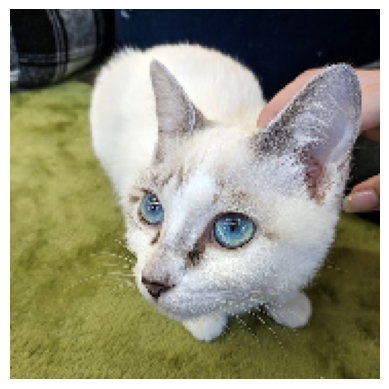

In [9]:
import matplotlib.pyplot as plt

plt.axis("off")
plt.imshow(img_tensor[0].astype("uint8"))
plt.show()

In [10]:
from keras import layers

layer_outputs = []
layer_names = []
for layer in model.layers:
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)):
        layer_outputs.append(layer.output)
        layer_names.append(layer.name)
activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

In [11]:
activations = activation_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [12]:
first_layer_activation = activations[0]
print(first_layer_activation.shape)

(1, 178, 178, 32)


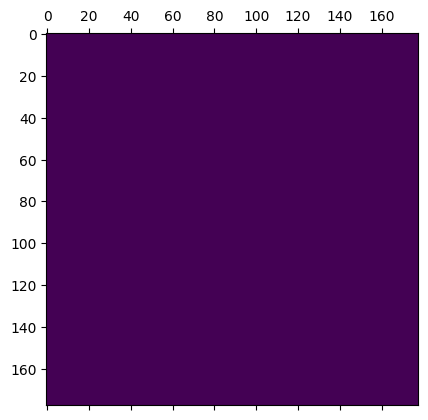

In [13]:
import matplotlib.pyplot as plt

plt.matshow(first_layer_activation[0, :, :, 5], cmap="viridis")

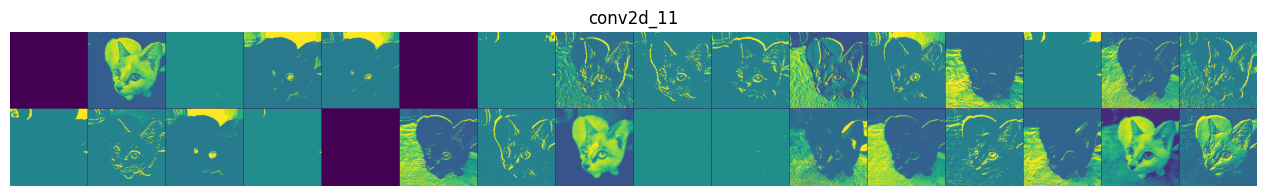

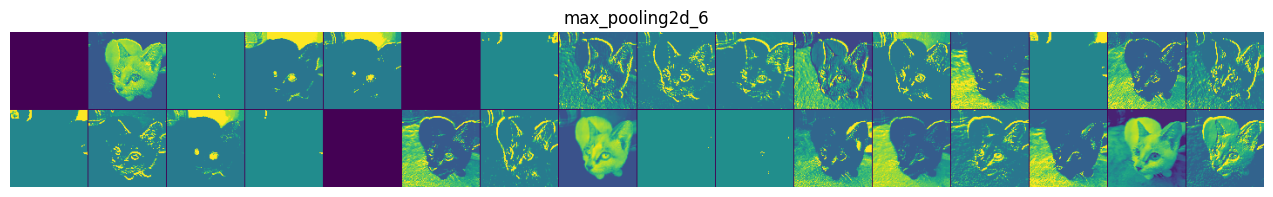

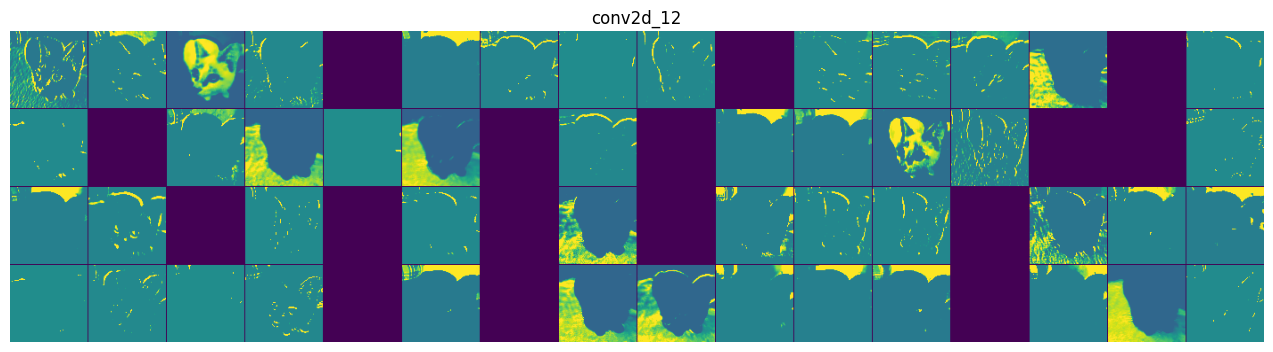

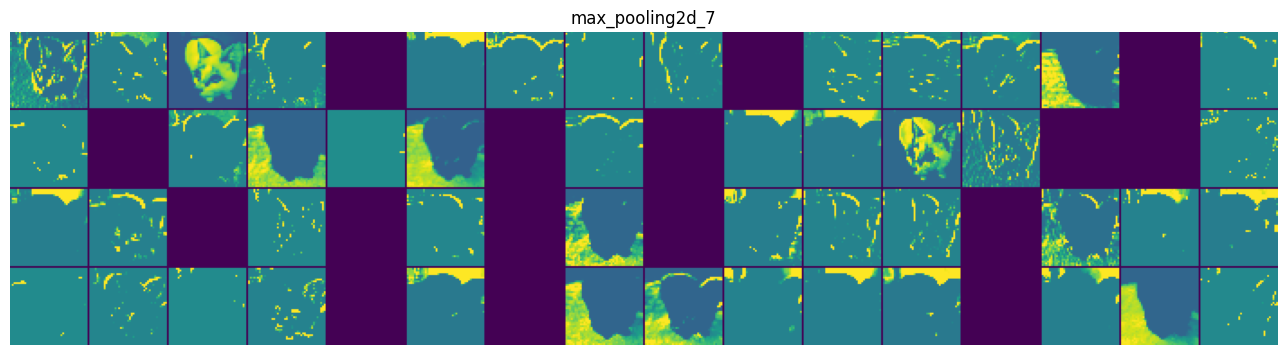

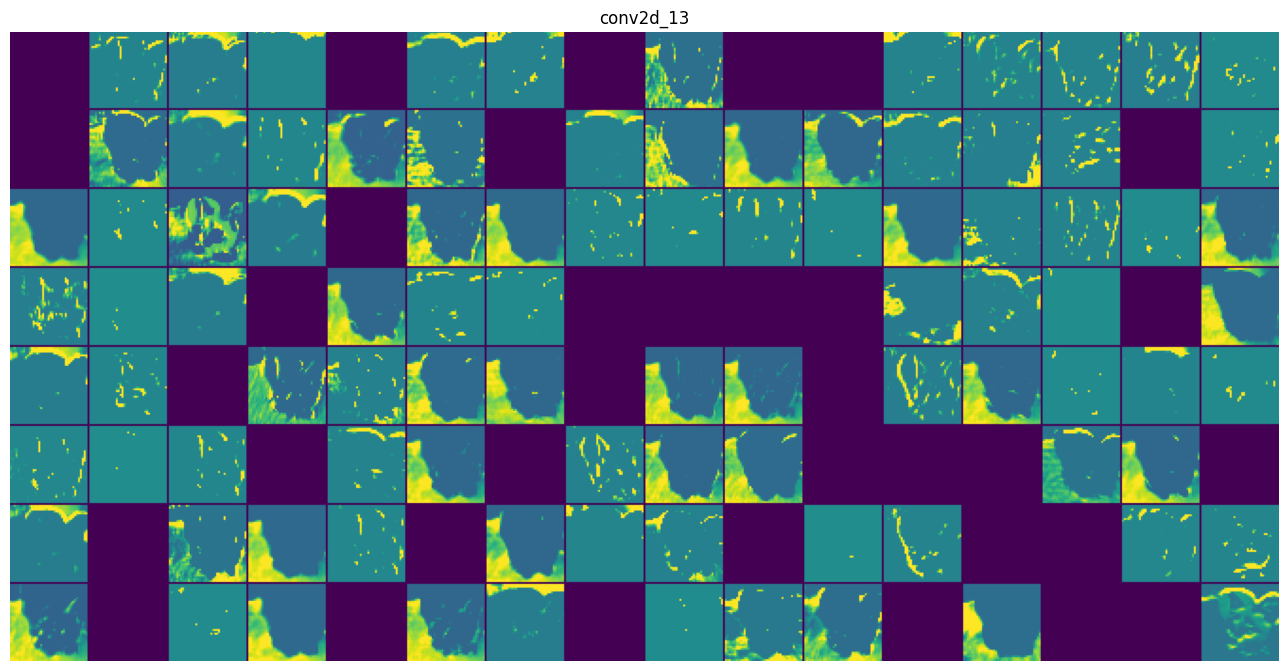

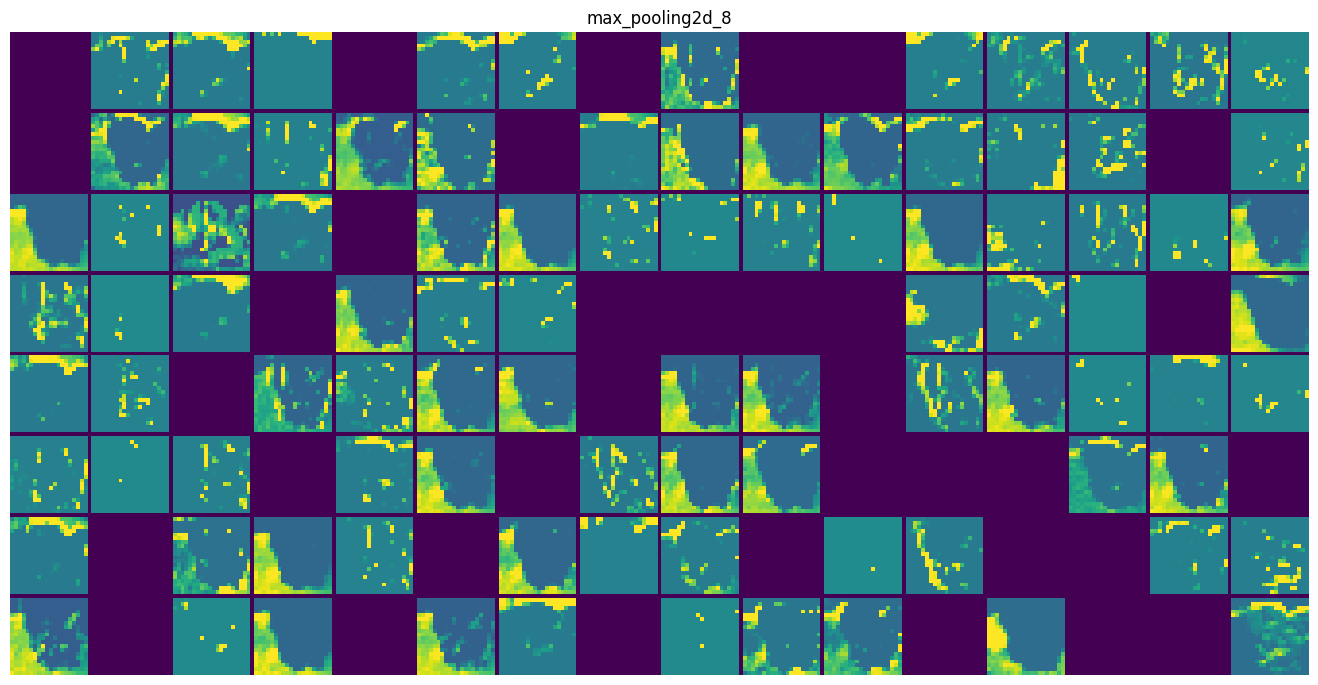

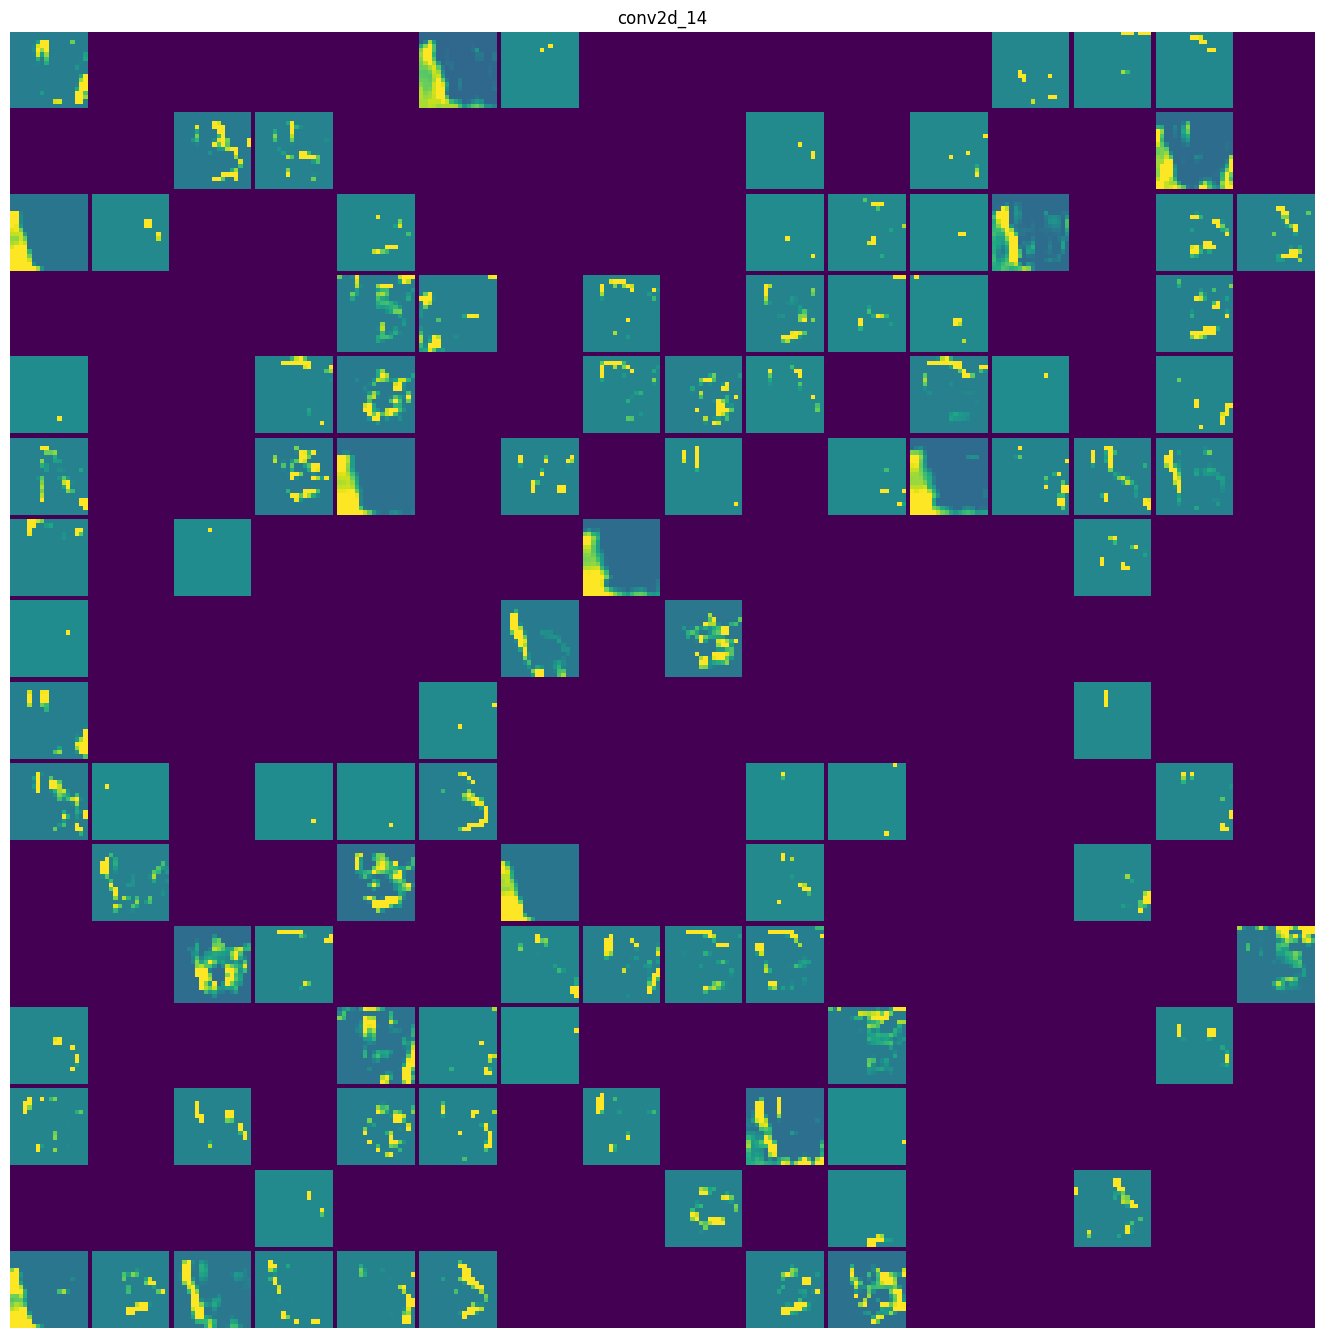

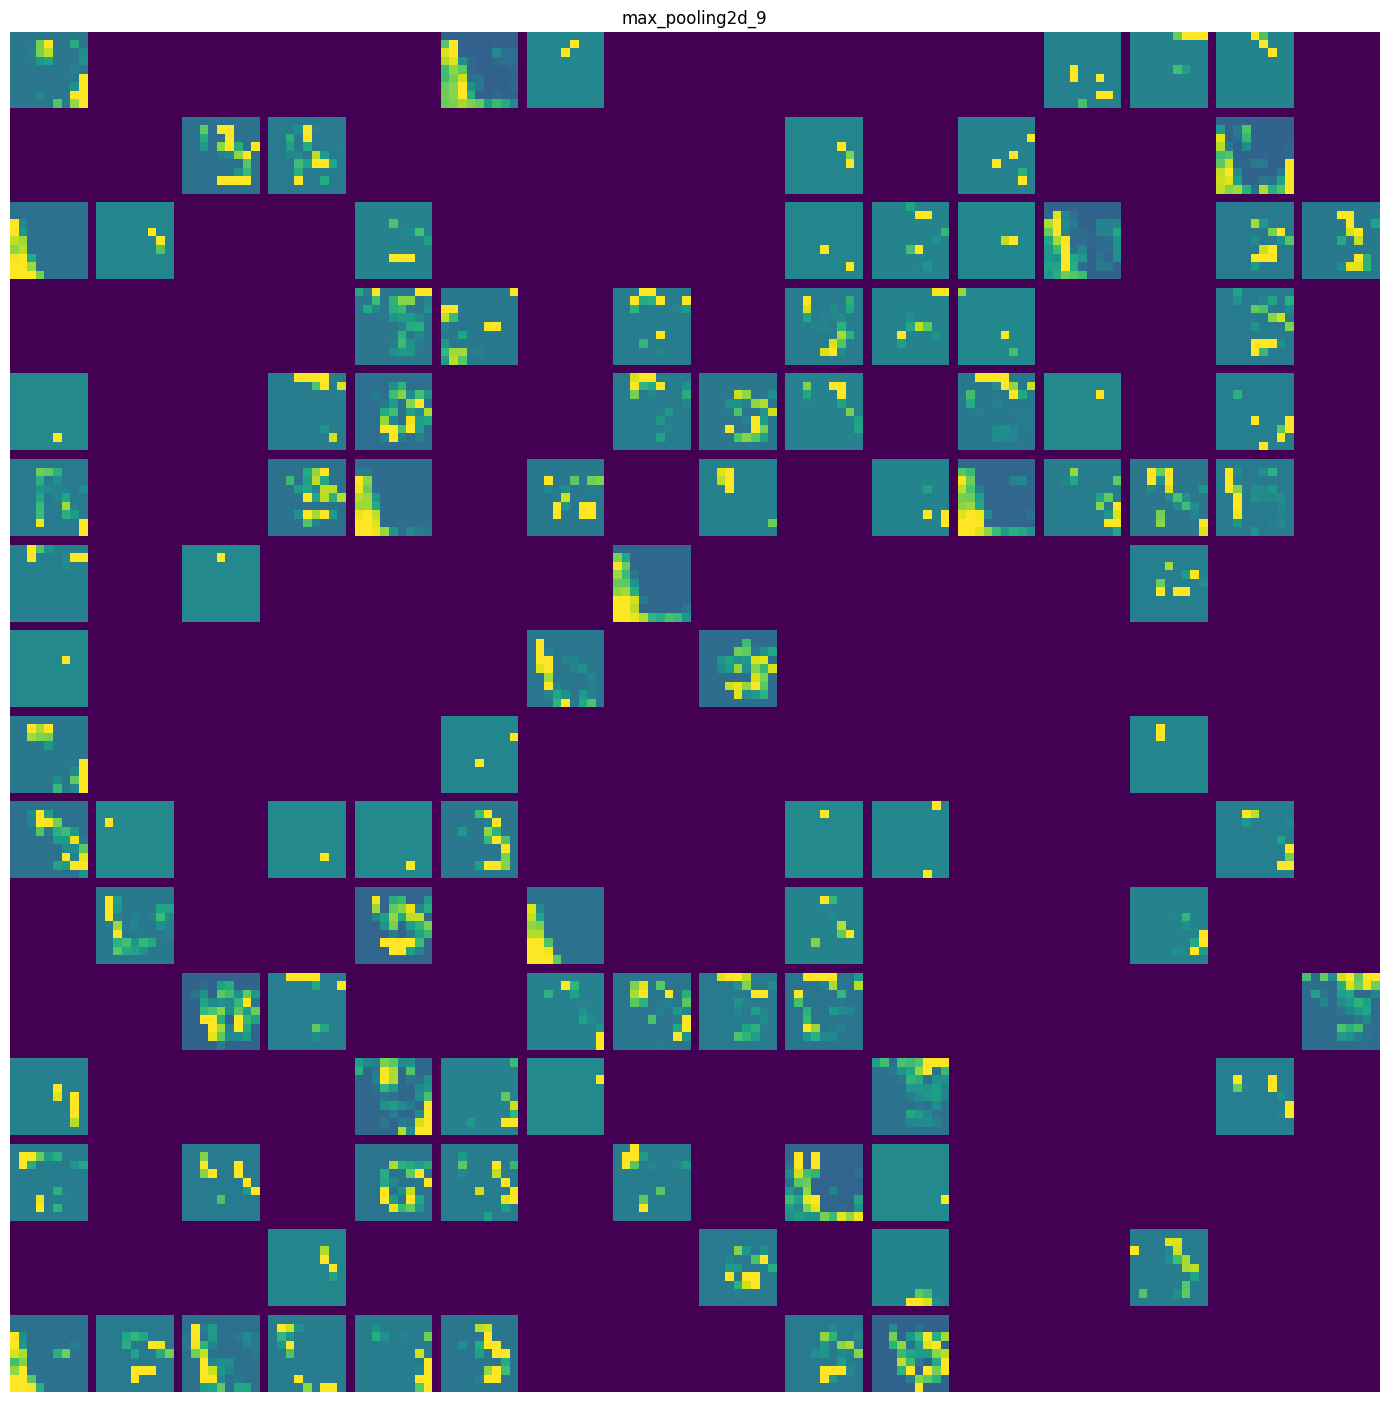

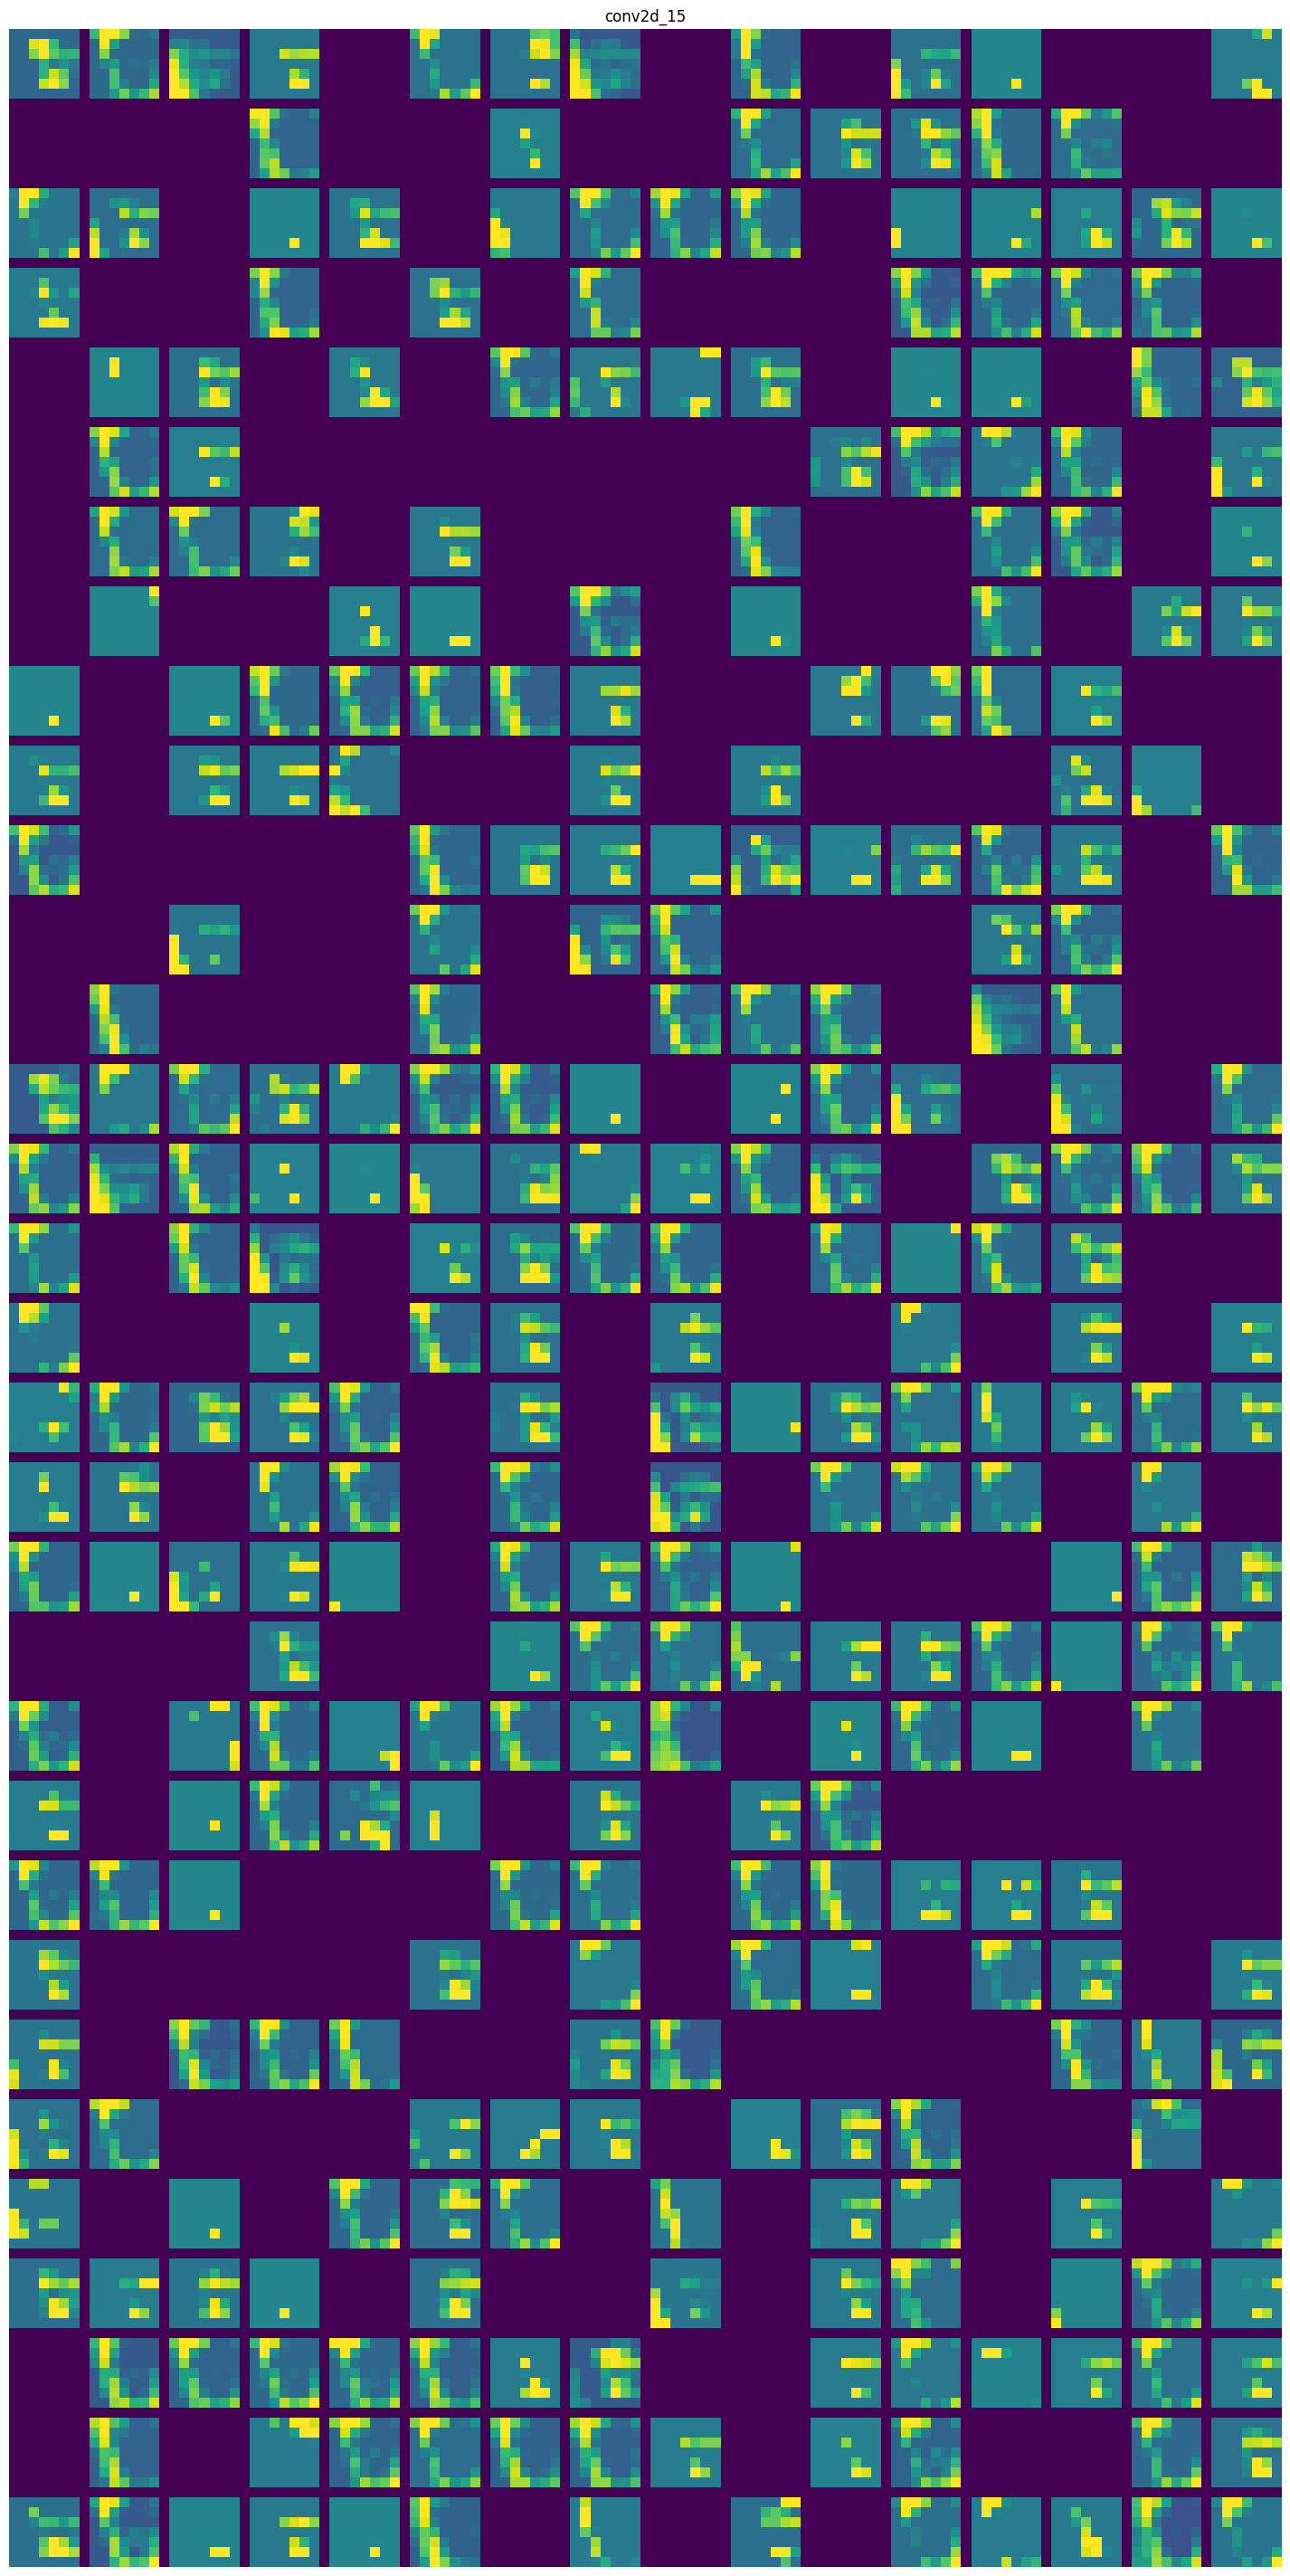

In [14]:
images_per_row = 16
for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    n_cols = n_features // images_per_row
    display_grid = np.zeros(
        ((size + 1) * n_cols - 1, images_per_row * (size + 1) - 1)
    )
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_index = col * images_per_row + row
            channel_image = layer_activation[0, :, :, channel_index].copy()
            if channel_image.sum() != 0:
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype("uint8")
            display_grid[
                col * (size + 1) : (col + 1) * size + col,
                row * (size + 1) : (row + 1) * size + row,
            ] = channel_image
    scale = 1.0 / size
    plt.figure(
        figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0])
    )
    plt.title(layer_name)
    plt.grid(False)
    plt.axis("off")
    plt.imshow(display_grid, aspect="auto", cmap="viridis")

### 컨브넷 필터 시각화하기

In [15]:
import keras_hub

model = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
)
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

In [16]:
for layer in model.layers:
    if isinstance(layer, (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
        print(layer.name)

block1_conv1
block1_conv2
block2_sepconv1
block2_sepconv2
block2_residual_conv
block3_sepconv1
block3_sepconv2
block3_residual_conv
block4_sepconv1
block4_sepconv2
block4_residual_conv
block5_sepconv1
block5_sepconv2
block5_sepconv3
block6_sepconv1
block6_sepconv2
block6_sepconv3
block7_sepconv1
block7_sepconv2
block7_sepconv3
block8_sepconv1
block8_sepconv2
block8_sepconv3
block9_sepconv1
block9_sepconv2
block9_sepconv3
block10_sepconv1
block10_sepconv2
block10_sepconv3
block11_sepconv1
block11_sepconv2
block11_sepconv3
block12_sepconv1
block12_sepconv2
block12_sepconv3
block13_sepconv1
block13_sepconv2
block13_residual_conv
block14_sepconv1
block14_sepconv2


In [17]:
layer_name = "block3_sepconv1"
layer = model.get_layer(name=layer_name)
feature_extractor = keras.Model(inputs=model.input, outputs=layer.output)

In [18]:
activation = feature_extractor(preprocessor(img_tensor))

In [19]:
from keras import ops

def compute_loss(image, filter_index):
    activation = feature_extractor(image)
    filter_activation = activation[:, 2:-2, 2:-2, filter_index]
    return ops.mean(filter_activation)

#### 텐서플로로 경사 상승법 수행하기

In [20]:
%%backend tensorflow
import tensorflow as tf

@tf.function
def gradient_ascent_step(image, filter_index, learning_rate):
    with tf.GradientTape() as tape:
        tape.watch(image)
        loss = compute_loss(image, filter_index)
    grads = tape.gradient(loss, image)
    grads = ops.normalize(grads)
    image += learning_rate * grads
    return image

이 셀은 tensorflow 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "tensorflow"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요.


#### 파이토치로 경사 상승법 수행하기

In [21]:
%%backend torch
import torch

def gradient_ascent_step(image, filter_index, learning_rate):
    image = image.clone().detach().requires_grad_(True)
    loss = compute_loss(image, filter_index)
    loss.backward()
    grads = image.grad
    grads = ops.normalize(grads)
    image = image + learning_rate * grads
    return image

이 셀은 torch 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "torch"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요.


#### JAX로 경사 상승법 수행하기

In [22]:
%%backend jax
import jax

grad_fn = jax.grad(compute_loss)

@jax.jit
def gradient_ascent_step(image, filter_index, learning_rate):
    grads = grad_fn(image, filter_index)
    grads = ops.normalize(grads)
    image += learning_rate * grads
    return image

#### 필터 시각화 루프

In [23]:
img_width = 200
img_height = 200

def generate_filter_pattern(filter_index):
    iterations = 30
    learning_rate = 10.0
    image = keras.random.uniform(
        minval=0.4, maxval=0.6, shape=(1, img_width, img_height, 3)
    )
    for i in range(iterations):
        image = gradient_ascent_step(image, filter_index, learning_rate)
    return image[0]

In [24]:
def deprocess_image(image):
    image -= ops.mean(image)
    image /= ops.std(image)
    image *= 64
    image += 128
    image = ops.clip(image, 0, 255)
    image = image[25:-25, 25:-25, :]
    image = ops.cast(image, dtype="uint8")
    return ops.convert_to_numpy(image)

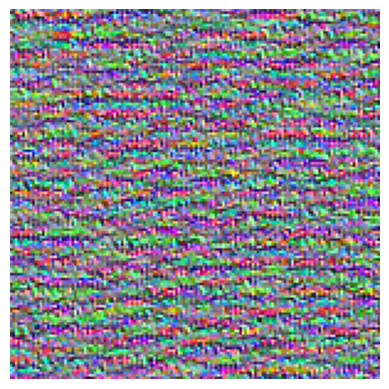

In [25]:
plt.axis("off")
plt.imshow(deprocess_image(generate_filter_pattern(filter_index=2)))

In [26]:
all_images = []
for filter_index in range(64):
    print(f"필터 {filter_index} 처리 중")
    image = deprocess_image(generate_filter_pattern(filter_index))
    all_images.append(image)

margin = 5
n = 8
box_width = img_width - 25 * 2
box_height = img_height - 25 * 2
full_width = n * box_width + (n - 1) * margin
full_height = n * box_height + (n - 1) * margin
stitched_filters = np.zeros((full_width, full_height, 3))

for i in range(n):
    for j in range(n):
        image = all_images[i * n + j]
        stitched_filters[
            (box_width + margin) * i : (box_width + margin) * i + box_width,
            (box_height + margin) * j : (box_height + margin) * j + box_height,
            :,
        ] = image

keras.utils.save_img(f"filters_for_layer_{layer_name}.png", stitched_filters)

필터 0 처리 중
필터 1 처리 중
필터 2 처리 중
필터 3 처리 중
필터 4 처리 중
필터 5 처리 중
필터 6 처리 중
필터 7 처리 중
필터 8 처리 중
필터 9 처리 중
필터 10 처리 중
필터 11 처리 중
필터 12 처리 중
필터 13 처리 중
필터 14 처리 중
필터 15 처리 중
필터 16 처리 중
필터 17 처리 중
필터 18 처리 중
필터 19 처리 중
필터 20 처리 중
필터 21 처리 중
필터 22 처리 중
필터 23 처리 중
필터 24 처리 중
필터 25 처리 중
필터 26 처리 중
필터 27 처리 중
필터 28 처리 중
필터 29 처리 중
필터 30 처리 중
필터 31 처리 중
필터 32 처리 중
필터 33 처리 중
필터 34 처리 중
필터 35 처리 중
필터 36 처리 중
필터 37 처리 중
필터 38 처리 중
필터 39 처리 중
필터 40 처리 중
필터 41 처리 중
필터 42 처리 중
필터 43 처리 중
필터 44 처리 중
필터 45 처리 중
필터 46 처리 중
필터 47 처리 중
필터 48 처리 중
필터 49 처리 중
필터 50 처리 중
필터 51 처리 중
필터 52 처리 중
필터 53 처리 중
필터 54 처리 중
필터 55 처리 중
필터 56 처리 중
필터 57 처리 중
필터 58 처리 중
필터 59 처리 중
필터 60 처리 중
필터 61 처리 중
필터 62 처리 중
필터 63 처리 중


### 클래스 활성화의 히트맵 시각화하기

In [27]:
img_path = keras.utils.get_file(
    fname="elephant.jpg",
    origin="https://img-datasets.s3.amazonaws.com/elephant.jpg",
)
img = keras.utils.load_img(img_path)
img_array = np.expand_dims(img, axis=0)

In [28]:
model = keras_hub.models.ImageClassifier.from_preset(
   "xception_41_imagenet",
   activation="softmax",
)
preds = model.predict(img_array)
preds.shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'xception_image_classifier', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


(1, 1000)

In [29]:
keras_hub.utils.decode_imagenet_predictions(preds)

[[('African_elephant', 0.9033181667327881),
  ('tusker', 0.054871004074811935),
  ('Indian_elephant', 0.01637868955731392),
  ('triceratops', 0.00029663179884664714),
  ('Mexican_hairless', 0.00018873144290409982)]]

In [30]:
np.argmax(preds[0])

np.int64(386)

In [31]:
img_array = model.preprocessor(img_array)

In [32]:
last_conv_layer_name = "block14_sepconv2_act"
last_conv_layer = model.backbone.get_layer(last_conv_layer_name)
last_conv_layer_model = keras.Model(model.inputs, last_conv_layer.output)

In [33]:
classifier_input = last_conv_layer.output
x = classifier_input
for layer_name in ["pooler", "predictions"]:
    x = model.get_layer(layer_name)(x)
classifier_model = keras.Model(classifier_input, x)

#### 최상위 클래스에 대한 그레이디언트 계산하기: 텐서플로 버전

In [34]:
%%backend tensorflow
import tensorflow as tf

def get_top_class_gradients(img_array):
    last_conv_layer_output = last_conv_layer_model(img_array)
    with tf.GradientTape() as tape:
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)
        top_pred_index = ops.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, last_conv_layer_output)
    return grads, last_conv_layer_output

grads, last_conv_layer_output = get_top_class_gradients(img_array)
grads = ops.convert_to_numpy(grads)
last_conv_layer_output = ops.convert_to_numpy(last_conv_layer_output)

이 셀은 tensorflow 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "tensorflow"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요.


#### 최상위 클래스에 대한 그레이디언트 계산하기: 파이토치 버전

In [35]:
%%backend torch
def get_top_class_gradients(img_array):
    last_conv_layer_output = last_conv_layer_model(img_array)
    last_conv_layer_output = (
        last_conv_layer_output.clone().detach().requires_grad_(True)
    )
    preds = classifier_model(last_conv_layer_output)
    top_pred_index = ops.argmax(preds[0])
    top_class_channel = preds[:, top_pred_index]
    top_class_channel.backward()
    grads = last_conv_layer_output.grad
    return grads, last_conv_layer_output

grads, last_conv_layer_output = get_top_class_gradients(img_array)
grads = ops.convert_to_numpy(grads)
last_conv_layer_output = ops.convert_to_numpy(last_conv_layer_output)

이 셀은 torch 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "torch"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요.


#### 최상위 클래스에 대한 그레이디언트 계산하기: JAX 버전

In [36]:
%%backend jax
import jax

def loss_fn(last_conv_layer_output):
    preds = classifier_model(last_conv_layer_output)
    top_pred_index = ops.argmax(preds[0])
    top_class_channel = preds[:, top_pred_index]
    return top_class_channel[0]

grad_fn = jax.grad(loss_fn)

def get_top_class_gradients(img_array):
    last_conv_layer_output = last_conv_layer_model(img_array)
    grads = grad_fn(last_conv_layer_output)
    return grads, last_conv_layer_output

grads, last_conv_layer_output = get_top_class_gradients(img_array)
grads = ops.convert_to_numpy(grads)
last_conv_layer_output = ops.convert_to_numpy(last_conv_layer_output)

#### 클래스 활성화 히트맵 그리기

In [37]:
pooled_grads = np.mean(grads, axis=(0, 1, 2))
last_conv_layer_output = last_conv_layer_output[0].copy()
for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]
heatmap = np.mean(last_conv_layer_output, axis=-1)

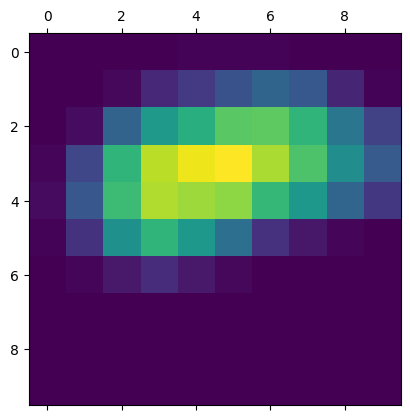

In [38]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.matshow(heatmap)

/tmp/ipykernel_4040/1358311572.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


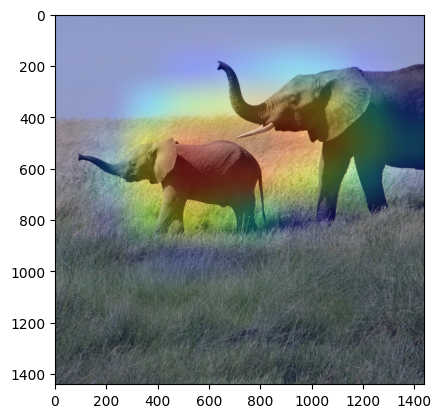

In [39]:
import matplotlib.cm as cm

img = keras.utils.load_img(img_path)
img = keras.utils.img_to_array(img)

heatmap = np.uint8(255 * heatmap)

jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

jet_heatmap = keras.utils.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.utils.img_to_array(jet_heatmap)

superimposed_img = jet_heatmap * 0.4 + img
superimposed_img = keras.utils.array_to_img(superimposed_img)

plt.imshow(superimposed_img)

### 컨브넷의 잠재 공간 시각화하기